# 03 — CNN Cloud Segmentation (U-Net)

## Executive Summary
**Architecture:** U-Net with ResNet-34 encoder pretrained on ImageNet, fine-tuned
on the combined ACS_WSI + manual dataset.

**Input:** 512×512 RGB dome crop, normalised to ImageNet mean/std.  
**Output:** Binary cloud mask (1 = cloud, 0 = sky) + cloud fraction float.

**Minimum labels for reliable fine-tuning:**  
~30–50 images spread across clear / partial / overcast conditions.
ACS_WSI alone (77 pairs) is sufficient for a first working model.
Adding 10–20 manually labelled Warsaw images typically improves local performance.

**Pipeline:**
1. Build combined dataset; randomly split manual masks into train/val/test; all ACS_WSI goes to train+val
2. Train U-Net with early stopping
3. Evaluate on held-out manual test set (20% of manual, random split)
4. Run on all daytime pilot images → `outputs/csv/cf_cnn.csv`
5. Compare CNN vs R/B threshold

In [1]:
import sys, logging
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s | %(name)s | %(message)s',
                    datefmt='%H:%M:%S')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from skycamera.config import CX, CY, R, CSV_DIR, PLOTS_DIR, MASKS_PRED_DIR, MODEL_DIR, FULL_RAW_DIR, CF_MAX_ZENITH_DEG
from skycamera.io import load_image, build_combined_dataset, build_image_index
from skycamera.preprocessing import (
    build_circular_mask, build_zenith_weight_map, weighted_cf, _infer_dome_params,
)
from skycamera.cnn import (
    train_cnn, predict_mask, load_cnn_model, run_cnn_on_index,
    EPOCHS, BATCH_SIZE, LR, IMG_SIZE
)

RAW_ROOT = FULL_RAW_DIR   # data/full_raw/ — full year, thinned to 30-min intervals
ACS_ROOT = Path('D:/MOJE/DATA_SCIENCE/SKYCAMERA/ACS_WSI-v1.0.0')
MANUAL_MASKS = Path('..') / 'data' / 'masks_manual'
MODEL_PATH   = Path('..') / 'outputs' / 'models' / 'cnn_sky.pt'

for d in [CSV_DIR, PLOTS_DIR, MASKS_PRED_DIR, MODEL_PATH.parent]:
    Path(d).mkdir(parents=True, exist_ok=True)

# Dome mask and zenith weight map at native resolution
_sample_path = next(FULL_RAW_DIR.rglob('*.jpg'))
_s = load_image(_sample_path)
dome_mask     = build_circular_mask(_s.shape[0], _s.shape[1], CX, CY, R)
zenith_weights = build_zenith_weight_map(_s.shape[0], _s.shape[1], CX, CY, R, CF_MAX_ZENITH_DEG)
print(f'Setup complete  |  dome pixels: {dome_mask.sum():,}  '
      f'|  CF max zenith: {CF_MAX_ZENITH_DEG}°')
print(f'Image root: {RAW_ROOT}')

Setup complete  |  dome pixels: 2,762,359  |  CF max zenith: 70.0°
Image root: D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\data\full_raw


## 1. Build combined dataset and stratified train/val/test split

**Split strategy:**
- Manual masks (Warsaw pilot camera) are split randomly 60/20/20 into train/val/test.
  The test set is the held-out evaluation set — same camera, same conditions as inference.
- All ACS_WSI pairs go into train+val only (stratified by CF level), never into the test set.
  ACS_WSI uses a different camera so it is not suitable as a test proxy for Warsaw images.
- If fewer than 5 manual masks exist, all manual images go to training and a warning is shown.

In [2]:
df_all = build_combined_dataset(ACS_ROOT, MANUAL_MASKS)
print(f'Total pairs: {len(df_all)}')

df_acs    = df_all[df_all['source'] == 'acs_wsi'].copy()
df_manual = df_all[df_all['source'] == 'manual'].copy()

# --- Manual split: 60/20/20 train/val/test (random, reproducible) ---
MIN_MANUAL_FOR_SPLIT = 5
if len(df_manual) >= MIN_MANUAL_FOR_SPLIT:
    df_manual_trainval, df_test = train_test_split(
        df_manual, test_size=0.20, random_state=42
    )
    df_manual_train, df_manual_val = train_test_split(
        df_manual_trainval, test_size=0.25, random_state=42  # 0.25 * 0.80 = 0.20
    )
else:
    print(f'WARNING: only {len(df_manual)} manual masks — skipping manual test split, '
          f'all manual images go to training.')
    df_manual_train = df_manual
    df_manual_val   = df_manual.iloc[0:0]   # empty
    df_test         = df_manual.iloc[0:0]   # empty

# --- ACS_WSI split: 80/20 train/val, stratified by CF level (no test) ---
df_acs_train, df_acs_val = train_test_split(
    df_acs, test_size=0.20, stratify=df_acs['cf_level'], random_state=42
)

# --- Combine ---
df_train = pd.concat([df_acs_train, df_manual_train], ignore_index=True)
df_val   = pd.concat([df_acs_val,   df_manual_val],   ignore_index=True)

print(f'Train : {len(df_train):>4d}  (ACS_WSI={len(df_acs_train)}  manual={len(df_manual_train)})')
print(f'Val   : {len(df_val):>4d}  (ACS_WSI={len(df_acs_val)}  manual={len(df_manual_val)})')
print(f'Test  : {len(df_test):>4d}  (manual only — held-out Warsaw images)')

Combined dataset summary
  ACS_WSI pairs  : 77
  Manual pairs   : 627
  Total          : 704

  CF measured — mean=0.571  std=0.432  min=0.000  max=1.000

  Class balance (by measured CF):
    Clear   (<0.2) : 229  (32.5%)
    Partial (0.2–0.8): 144  (20.5%)
    Cloudy  (>0.8) : 331  (47.0%)
Total pairs: 704
Train :  436  (ACS_WSI=61  manual=375)
Val   :  142  (ACS_WSI=16  manual=126)
Test  :  126  (manual only — held-out Warsaw images)


## 2. Train U-Net

In [3]:
# Training cell commented out — model weights unchanged after sun mask fix.
# Re-enable only if you need to retrain from scratch.
# Delete outputs/models/cnn_sky.pt first if retraining.

if MODEL_PATH.exists():
    print(f'Loading existing model from {MODEL_PATH}')
    model = load_cnn_model(MODEL_PATH)
    history = None
else:
    model, history = train_cnn(
        df_train, df_val,
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
        patience=7,
        save_path=MODEL_PATH,
        img_size=IMG_SIZE,
    )
print('Done.')

Loading existing model from ..\outputs\models\cnn_sky.pt
Done.


## 3. Training curves

In [4]:
if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE loss')
    axes[0].set_title('Loss curves'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history['train_iou'], label='Train')
    axes[1].plot(history['val_iou'],   label='Val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean IoU')
    axes[1].set_title('IoU curves'); axes[1].legend(); axes[1].grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'cnn_training_curves.png', bbox_inches='tight', dpi=100)
    plt.show()
else:
    print('(Model loaded from checkpoint — no training history available)')

(Model loaded from checkpoint — no training history available)


## 4. Evaluation on held-out manual test set

Metrics: MAE on cloud fraction, mean IoU, Pearson r vs GT cloud fraction.
Test set = 20% of manual Warsaw images, never seen during training.
Uses the pilot camera dome mask and zenith weights (same geometry as inference).

If no manual test images exist yet, this cell prints a notice and skips.

In [5]:
from skycamera.labelling import load_existing_mask, LABEL_CLOUD, LABEL_SKY

if len(df_test) == 0:
    print('No manual test images available — add more labelled masks and re-run cell 1.')
else:
    gt_cfs, pred_cfs, pred_ious = [], [], []

    for _, row in df_test.iterrows():
        img      = load_image(Path(row['image_path']))
        gt_mask  = load_existing_mask(Path(row['mask_path']))

        # Area-weighted GT CF using pilot camera geometry
        gt_cf = weighted_cf(gt_mask, zenith_weights)

        cf_pred, pred_mask = predict_mask(
            model, img, dome_mask, IMG_SIZE, weights=zenith_weights,
            image_path=Path(row['image_path'])
        )

        # IoU — only over sky/cloud pixels (exclude IGNORE/UNLABELLED)
        valid  = (gt_mask == LABEL_CLOUD) | (gt_mask == LABEL_SKY)
        gt_bin = (gt_mask == LABEL_CLOUD).astype(np.uint8)
        inter  = (pred_mask & gt_bin & valid).sum()
        union  = ((pred_mask | gt_bin) & valid).sum()
        iou    = inter / union if union > 0 else 0.0

        gt_cfs.append(gt_cf)
        pred_cfs.append(cf_pred)
        pred_ious.append(iou)

    gt_arr   = np.array(gt_cfs)
    pred_arr = np.array(pred_cfs)
    iou_arr  = np.array(pred_ious)
    ok       = ~np.isnan(gt_arr) & ~np.isnan(pred_arr)

    mae  = float(np.mean(np.abs(pred_arr[ok] - gt_arr[ok])))
    r    = float(np.corrcoef(gt_arr[ok], pred_arr[ok])[0, 1]) if ok.sum() > 2 else float('nan')
    miou = float(iou_arr.mean())

    print(f'Test set ({ok.sum()} manual Warsaw images, area-weighted CF):')
    print(f'  MAE (CF)   : {mae:.4f}')
    print(f'  Pearson r  : {r:.4f}')
    print(f'  Mean IoU   : {miou:.4f}')

Test set (126 manual Warsaw images, area-weighted CF):
  MAE (CF)   : 0.0645
  Pearson r  : 0.9501
  Mean IoU   : 0.4409


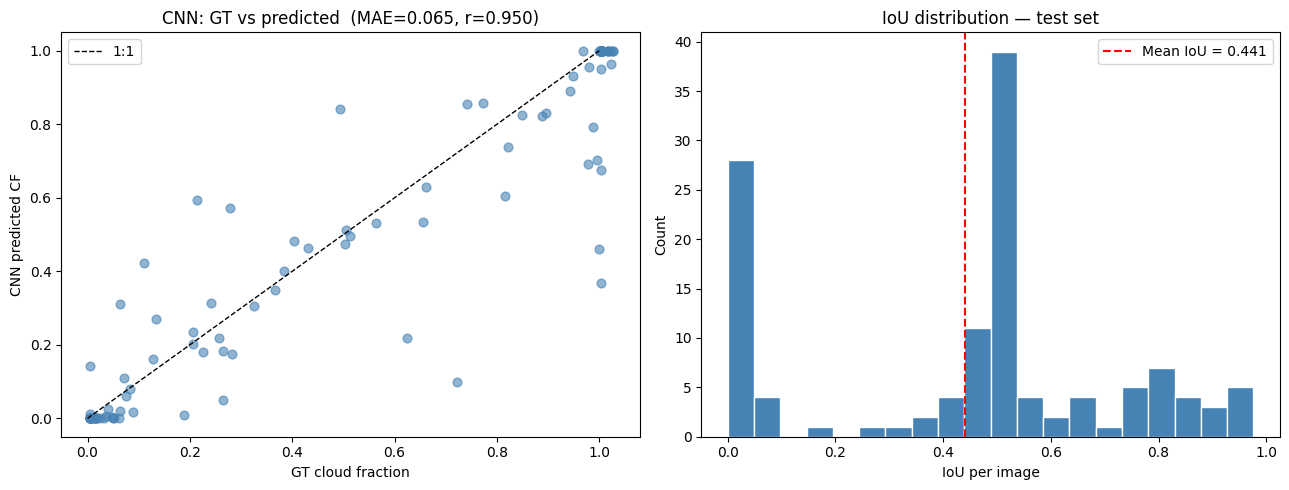

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(gt_arr[ok], pred_arr[ok], alpha=0.6, color='steelblue', s=40)
axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='1:1')
axes[0].set_xlabel('GT cloud fraction'); axes[0].set_ylabel('CNN predicted CF')
axes[0].set_title(f'CNN: GT vs predicted  (MAE={mae:.3f}, r={r:.3f})')
axes[0].legend()

axes[1].hist(iou_arr, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(miou, color='red', linestyle='--', linewidth=1.5,
                label=f'Mean IoU = {miou:.3f}')
axes[1].set_xlabel('IoU per image'); axes[1].set_ylabel('Count')
axes[1].set_title('IoU distribution — test set')
axes[1].legend()

fig.tight_layout()
fig.savefig(PLOTS_DIR / 'cnn_test_evaluation.png', bbox_inches='tight', dpi=100)
plt.show()

## 5. Qualitative inspection — sample predictions

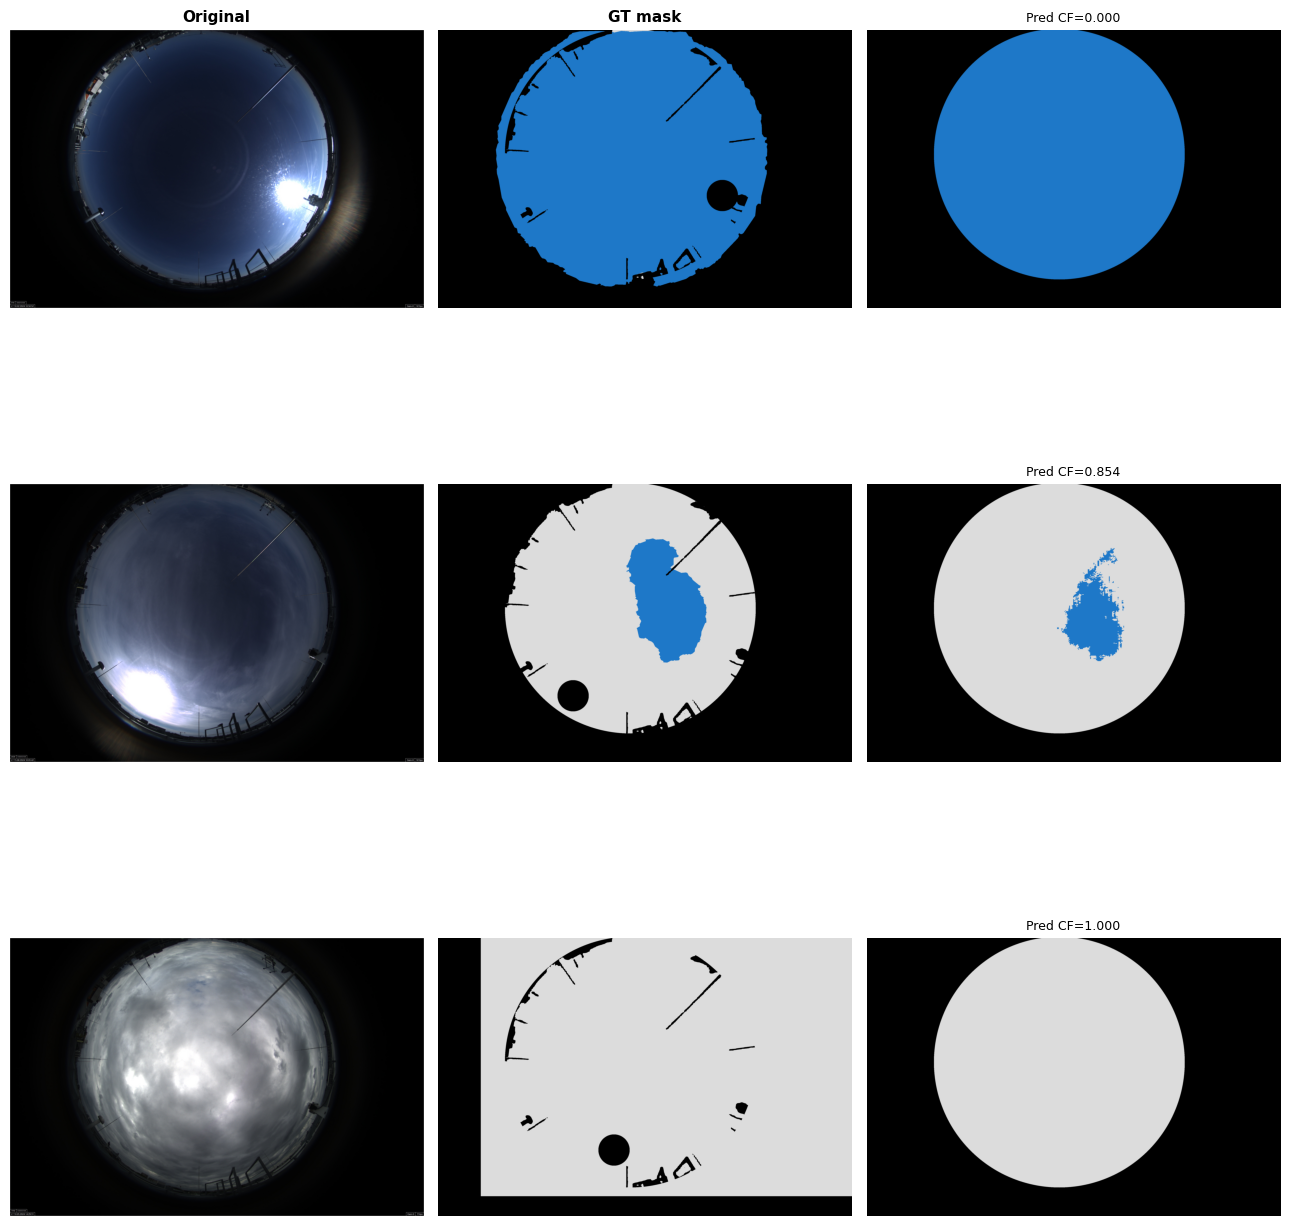

In [7]:
if len(df_test) == 0:
    print('No manual test images — skipping qualitative inspection.')
else:
    # Pick up to 3 samples spanning low / mid / high CF
    df_test_sorted = df_test.sort_values('cf_measured').reset_index(drop=True)
    indices = np.linspace(0, len(df_test_sorted) - 1, min(3, len(df_test_sorted)), dtype=int)
    samples = df_test_sorted.iloc[indices]

    fig, axes = plt.subplots(len(samples), 3, figsize=(13, 5 * len(samples)))
    if len(samples) == 1:
        axes = axes[np.newaxis, :]
    for ax, title in zip(axes[0], ['Original', 'GT mask', 'CNN prediction']):
        ax.set_title(title, fontsize=11, fontweight='bold')

    for row_idx, (_, row) in enumerate(samples.iterrows()):
        img     = load_image(Path(row['image_path']))
        gt_mask = load_existing_mask(Path(row['mask_path']))
        gt_cf   = weighted_cf(gt_mask, zenith_weights)

        cf_pred, pred_mask = predict_mask(
            model, img, dome_mask, IMG_SIZE, weights=zenith_weights,
            image_path=Path(row['image_path'])
        )

        gt_vis = np.zeros((*gt_mask.shape, 3), dtype=np.uint8)
        gt_vis[gt_mask == LABEL_CLOUD] = [220, 220, 220]
        gt_vis[gt_mask == LABEL_SKY]   = [30, 120, 200]

        pred_vis = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
        pred_vis[pred_mask == 1] = [220, 220, 220]
        pred_vis[pred_mask == 0] = [30, 120, 200]
        pred_vis[~dome_mask]     = [0, 0, 0]

        axes[row_idx][0].imshow(img)
        axes[row_idx][0].set_ylabel(
            f'{Path(row["image_path"]).stem}\nGT CF={gt_cf:.2f}', fontsize=8
        )
        axes[row_idx][1].imshow(gt_vis)
        axes[row_idx][2].imshow(pred_vis)
        axes[row_idx][2].set_title(f'Pred CF={cf_pred:.3f}', fontsize=9)
        for ax in axes[row_idx]:
            ax.axis('off')

    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'cnn_qualitative.png', bbox_inches='tight', dpi=100)
    plt.show()

## 6. Run CNN on all daytime pilot images

Results cached to `outputs/csv/cf_cnn.csv`.

In [8]:
CF_CNN_CSV = CSV_DIR / 'cf_cnn.csv'
INDEX_CSV  = CSV_DIR / 'image_index.csv'

if INDEX_CSV.exists():
    df_index = pd.read_csv(INDEX_CSV, parse_dates=['timestamp'])
    df_index['path'] = df_index['path'].apply(Path)
else:
    # Build index over ALL images (day + night) — CNN can run on everything
    df_index = build_image_index(RAW_ROOT, apply_daytime_filter=False)
    df_index.to_csv(INDEX_CSV, index=False)

print(f'Total images  : {len(df_index):,}')
print(f'Daytime       : {df_index["is_daytime"].sum():,}')
print(f'Night         : {(~df_index["is_daytime"]).sum():,}')

if CF_CNN_CSV.exists():
    print('Loading cached CNN results...')
    df_cnn = pd.read_csv(CF_CNN_CSV, parse_dates=['timestamp'])
else:
    print('Running CNN on all images (day + night)...')
    df_cnn = run_cnn_on_index(
        df_index, model, dome_mask, IMG_SIZE,
        save_masks=False, masks_dir=MASKS_PRED_DIR,
        weights=zenith_weights,
    )
    df_cnn.to_csv(CF_CNN_CSV, index=False)
    print(f'Saved -> {CF_CNN_CSV}')

print(f'Results: {len(df_cnn):,} images')
print(f'CF: mean={df_cnn["cloud_fraction"].mean():.3f}  std={df_cnn["cloud_fraction"].std():.3f}')
df_cnn.head()

Total images  : 17,145
Daytime       : 9,637
Night         : 7,508
Running CNN on all images (day + night)...
[   24] 2024-01-02 00:28:11  CF=1.0000
[   48] 2024-01-02 12:03:53  CF=1.0000
[   72] 2024-01-03 00:57:25  CF=1.0000
[   96] 2024-01-03 12:57:43  CF=1.0000
[  120] 2024-01-04 01:31:58  CF=1.0000
[  144] 2024-01-04 13:31:21  CF=1.0000
[  168] 2024-01-05 02:28:01  CF=1.0000
[  192] 2024-01-05 14:31:02  CF=1.0000
[  216] 2024-01-06 03:27:25  CF=1.0000
[  240] 2024-01-06 15:57:46  CF=1.0000
[  264] 2024-01-07 03:59:42  CF=1.0000
[  288] 2024-01-07 16:00:43  CF=1.0000
[  312] 2024-01-08 04:29:06  CF=1.0000
[  336] 2024-01-08 15:58:29  CF=0.0000
[  360] 2024-01-09 04:00:30  CF=0.0002
[  384] 2024-01-09 16:01:06  CF=0.0000
[  408] 2024-01-10 05:29:51  CF=0.0000
[  432] 2024-01-10 16:58:54  CF=0.9999
[  456] 2024-01-11 14:58:06  CF=1.0000
[  480] 2024-01-12 03:32:00  CF=0.4794
[  504] 2024-01-12 15:58:34  CF=1.0000
[  528] 2024-01-13 05:30:21  CF=1.0000
[  552] 2024-01-13 17:02:30  CF=

,timestamp,cloud_fraction,month,hour
0,2024-01-01 12:00:41,1.0,1,12
1,2024-01-01 12:31:23,1.0,1,12
2,2024-01-01 13:27:40,1.0,1,13
3,2024-01-01 13:58:20,1.0,1,13
4,2024-01-01 14:29:02,1.0,1,14


## 7. CNN vs R/B threshold comparison

Paired images: 9,276
CNN vs R/B: MAE=0.0641  Pearson r=0.9457


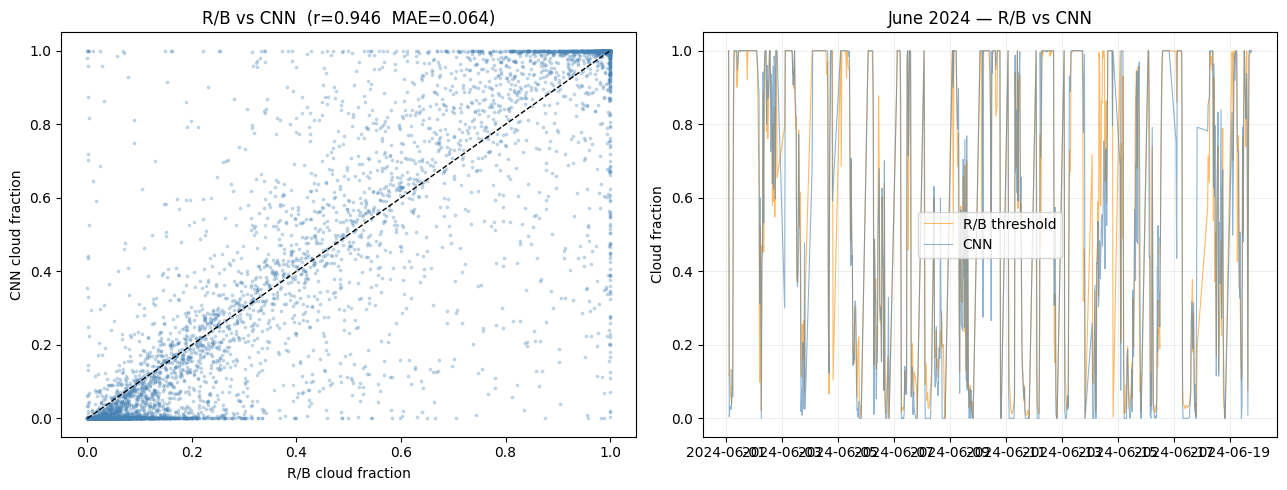

In [9]:
CF_RB_CSV = CSV_DIR / 'cf_rb_threshold.csv'

if not CF_RB_CSV.exists():
    print('R/B results not found — run notebook 02 first.')
else:
    df_rb = pd.read_csv(CF_RB_CSV, parse_dates=['timestamp'])
    merged = pd.merge(df_cnn.rename(columns={'cloud_fraction':'cf_cnn'}),
                      df_rb.rename(columns={'cloud_fraction':'cf_rb'}),
                      on='timestamp', how='inner')
    print(f'Paired images: {len(merged):,}')

    ok = merged['cf_cnn'].notna() & merged['cf_rb'].notna()
    mae_pair = float(np.mean(np.abs(merged.loc[ok,'cf_cnn'] - merged.loc[ok,'cf_rb'])))
    r_pair   = float(np.corrcoef(merged.loc[ok,'cf_cnn'], merged.loc[ok,'cf_rb'])[0,1])
    print(f'CNN vs R/B: MAE={mae_pair:.4f}  Pearson r={r_pair:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].scatter(merged.loc[ok,'cf_rb'], merged.loc[ok,'cf_cnn'],
                    s=3, alpha=0.25, color='steelblue')
    axes[0].plot([0,1],[0,1],'k--', linewidth=1)
    axes[0].set_xlabel('R/B cloud fraction'); axes[0].set_ylabel('CNN cloud fraction')
    axes[0].set_title(f'R/B vs CNN  (r={r_pair:.3f}  MAE={mae_pair:.3f})')

    # Time-series overlay for a single month (June)
    jun = merged[merged['timestamp'].dt.month == 6].set_index('timestamp').sort_index()
    if len(jun) > 0:
        axes[1].plot(jun.index, jun['cf_rb'],  alpha=0.6, linewidth=0.8,
                     color='darkorange', label='R/B threshold')
        axes[1].plot(jun.index, jun['cf_cnn'], alpha=0.6, linewidth=0.8,
                     color='steelblue', label='CNN')
        axes[1].set_ylabel('Cloud fraction')
        axes[1].set_title('June 2024 — R/B vs CNN')
        axes[1].legend(); axes[1].grid(alpha=0.2)

    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'cnn_vs_rb_comparison.png', bbox_inches='tight', dpi=100)
    plt.show()